In [20]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
#import kagglehub
import tensorflow as tf

from tensorflow.keras import layers, models, losses, optimizers


# Downloading and Reading the data


In [21]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train/255.
X_test = X_test/255.

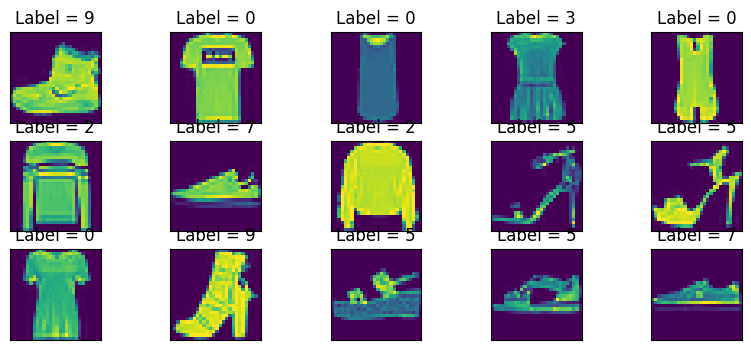

In [22]:

f, ax = plt.subplots(3,5, figsize=(10, 4))
ax = ax.flatten()

for i in range(15):
    ax[i].imshow(X_train[i,:,:])
    ax[i].set_title(f'Label = {y_train[i]}')
    ax[i].set_xticks([])
    ax[i].set_yticks([])

#plt.title('Sample of Training Data')

In [23]:
Inp = layers.Input((28,28,1), dtype='float32', name='Model_Input')
Conv1 = layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', name='conv_1')(Inp)
Pool1 = layers.MaxPool2D(pool_size=(2,2),
                         name='pool_1')(Conv1)
Conv2 = layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', name='conv_2')(Pool1)
Pool2 = layers.MaxPool2D(pool_size=(2,2),
                         name='pool_2')(Conv2)
Flat = layers.Flatten()(Pool2)
Dense1 = layers.Dense(64, activation='relu', name='fc_1')(Flat)
Dense2 = layers.Dense(10, name='fc_2')(Dense1)

In [25]:
model = models.Model(inputs=Inp, outputs=Dense2)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Model_Input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,634 (432.16 KB)

 Trainable params: 110,634 (432.16 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:

model.compile(optimizer=optimizers.Adam(),
                    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=['accuracy'])

In [27]:
history = model.fit(x=X_train, y=y_train, epochs=25,
                          validation_data=(X_test, y_test),
                          batch_size=512)

print(history.history.keys)

Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 25s 204ms/step - accuracy: 0.6142 - loss: 1.1599 - val_accuracy: 0.8136 - val_loss: 0.5033
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.8360 - loss: 0.4601 - val_accuracy: 0.8396 - val_loss: 0.4378
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.8599 - loss: 0.3955 - val_accuracy: 0.8623 - val_loss: 0.3886
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.8742 - loss: 0.3553 - val_accuracy: 0.8642 - val_loss: 0.3848
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - accuracy: 0.8833 - loss: 0.3355 - val_accuracy: 0.8785 - val_loss: 0.3479
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 189ms/step - accuracy: 0.8883 - loss: 0.3146 - val_accuracy: 0.8758 - val_loss: 0.3414
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.8946 - loss: 0.2967 - val_accuracy: 0.8853 - val_loss: 0.3257
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.9017 - loss: 0

313/313 - 1s - 3ms/step - accuracy: 0.9090 - loss: 0.2531


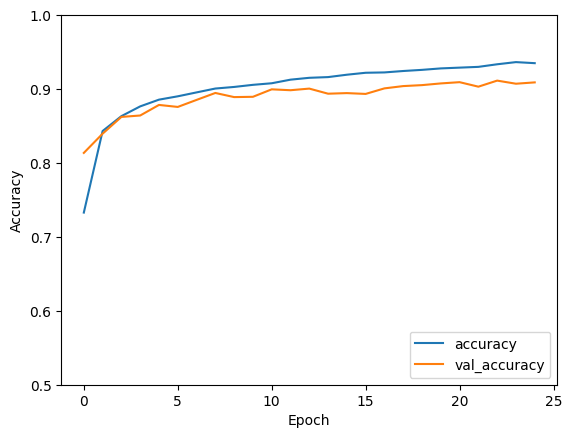

In [29]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

In [30]:
print(test_acc)

0.9089999794960022
